[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO/blob/main/Perotti_4a_machine_learning_TEMP.ipynb)

In [ ]:
# Yes, again..
# File -> Save a copy in Drive
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# Introduction to Machine Learning

---

## What is Machine Learning?

Machine learning is about teaching computers to learn patterns from data without being explicitly programmed.

**Three main types:**
- **Supervised learning**: Learn from labeled examples (today's focus)
- **Unsupervised learning**: Find patterns in unlabeled data (clustering, dimensionality reduction)
- **Reinforcement learning**: Learn by trial and error with rewards

**Scikit-learn** is the most popular Python library for machine learning:
- Simple, consistent API across all algorithms
- Built on NumPy, SciPy, and Matplotlib
- Excellent documentation and examples
- Great for learning and prototyping

Today we'll explore classic supervised learning algorithms and compare their performance!

---
## Classic ML Algorithms

### K-Nearest Neighbors (KNN)

**How it works:** To classify a new point, KNN looks at the K nearest training examples and takes a majority vote.

**Intuition:** "You are the average of your K closest friends"

**Pros:**
- Simple to understand and implement
- No training phase (just stores data)
- Works well for simple patterns

**Cons:**
- Slow prediction for large datasets
- Sensitive to irrelevant features
- Needs proper distance metric and K value

![KNN](knn.png)

### Support Vector Machine (SVM)

**How it works:** SVM finds the optimal hyperplane that maximally separates different classes. It focuses on the "support vectors" - the data points closest to the decision boundary.

**Intuition:** "Draw the widest possible line between classes"

**Kernels:** SVM can use different kernels to handle non-linear boundaries:
- Linear: Straight line separation
- RBF (Radial Basis Function): Can create circular/curved boundaries
- Polynomial: Creates polynomial decision boundaries

**Pros:**
- Effective in high dimensions
- Memory efficient (only stores support vectors)
- Versatile with different kernels

**Cons:**
- Can be slow to train on large datasets
- Requires feature scaling
- Hard to interpret

![SVM](svm.png)

### Decision Tree

**How it works:** A decision tree makes predictions by learning a series of if/then rules from the data. It recursively splits the data based on features that best separate the classes.

**Intuition:** "20 questions game" - Ask yes/no questions until you reach a conclusion

**Pros:**
- Easy to understand and visualize
- Requires little data preprocessing
- Can handle both numerical and categorical data
- Naturally handles non-linear relationships

**Cons:**
- Prone to overfitting (especially deep trees)
- Can be unstable (small data changes cause big tree changes)
- Biased toward features with more levels

![Decision Tree](dt.png)

### Multi-Layer Perceptron (MLP)

**How it works:** MLP is a neural network with multiple layers of neurons. Each neuron performs a weighted sum of inputs followed by a non-linear activation function. The network learns by adjusting weights through backpropagation.

**Intuition:** "A network of simple computational units working together to learn complex patterns"

**Structure:**
- Input layer: Receives features
- Hidden layer(s): Learn intermediate representations
- Output layer: Makes final predictions

**Pros:**
- Can learn complex non-linear relationships
- Scales well to large datasets
- Flexible architecture

**Cons:**
- Requires lots of data
- Many hyperparameters to tune
- Can be slow to train
- Black box (hard to interpret)

![MLP](mlp.png)

---
## Setup and Data Loading

**1. Import libraries** - Load all necessary packages

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time

**2. Load Iris dataset** - Small, simple dataset with 4 features

In [44]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"Iris dataset:")
print(f"  Samples: {X_iris.shape[0]}")
print(f"  Features: {X_iris.shape[1]}")
print(f"  Classes: {len(np.unique(y_iris))} - {iris.target_names}")
print(f"  Feature names: {iris.feature_names}")

Iris dataset:
  Samples: 150
  Features: 4
  Classes: 3 - ['setosa' 'versicolor' 'virginica']
  Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**3. Load MNIST dataset** - Large dataset with 784 features (28x28 pixels)

In [45]:
# Load MNIST dataset (use subset for faster training)
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X_mnist = mnist.data.values[:5000]  # Use 5000 samples for reasonable training time
y_mnist = mnist.target.values[:5000].astype(int)

print(f"\nMNIST dataset (subset):")
print(f"  Samples: {X_mnist.shape[0]}")
print(f"  Features: {X_mnist.shape[1]} (28×28 pixels)")
print(f"  Classes: {len(np.unique(y_mnist))} - Digits 0-9")
print(f"  Value range: {X_mnist.min():.0f} to {X_mnist.max():.0f}")

Loading MNIST dataset...

MNIST dataset (subset):
  Samples: 5000
  Features: 784 (28×28 pixels)
  Classes: 10 - Digits 0-9
  Value range: 0 to 255


**4. Visualize sample digits** - See what MNIST images look like

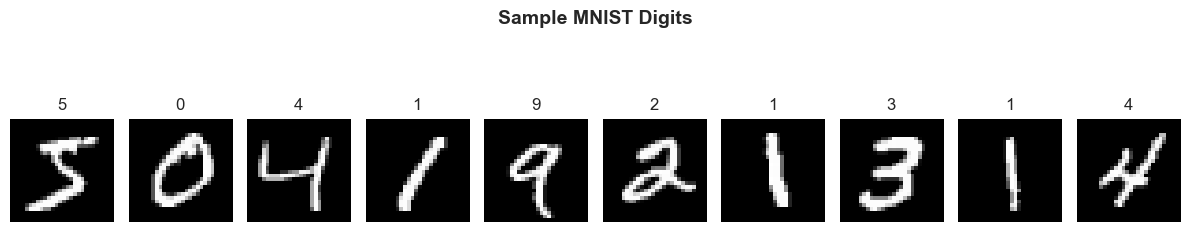

In [46]:
# Visualize some MNIST digits
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_mnist[i].reshape(28, 28), cmap='gray')
    plt.title(f'{y_mnist[i]}', fontsize=12)
    plt.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Random Forest vs MLP on Iris

**5. Prepare Iris data** - Split into train/test sets

In [47]:
# Split the data (smaller training set for more realistic results)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.5, random_state=42  # 50% test for smaller training set
)

# Scale features (important for MLP)
scaler_iris = StandardScaler()
X_train_iris_scaled = scaler_iris.fit_transform(X_train_iris)
X_test_iris_scaled = scaler_iris.transform(X_test_iris)

print(f"Training set: {X_train_iris.shape[0]} samples")
print(f"Test set: {X_test_iris.shape[0]} samples")

Training set: 75 samples
Test set: 75 samples


**6. Train Random Forest on Iris** - Ensemble of decision trees

In [48]:
# Train Random Forest
print("Training Random Forest on Iris...")
start_time = time.time()

# Simpler model that might make some mistakes
rf_iris = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
rf_iris.fit(X_train_iris, y_train_iris)

train_time_rf = time.time() - start_time

# Make predictions
y_pred_rf_iris = rf_iris.predict(X_test_iris)
accuracy_rf_iris = rf_iris.score(X_test_iris, y_test_iris)

print(f"Random Forest Accuracy: {accuracy_rf_iris:.3f}")
print(f"Training time: {train_time_rf:.3f}s")

Training Random Forest on Iris...
Random Forest Accuracy: 1.000
Training time: 0.008s


**7. Train MLP on Iris** - Neural network with hidden layers

In [49]:
# Train MLP
print("Training MLP on Iris...")
start_time = time.time()

# Simpler model with fewer iterations
mlp_iris = MLPClassifier(hidden_layer_sizes=(5,), max_iter=100, random_state=42)
mlp_iris.fit(X_train_iris_scaled, y_train_iris)

train_time_mlp = time.time() - start_time

# Make predictions
y_pred_mlp_iris = mlp_iris.predict(X_test_iris_scaled)
accuracy_mlp_iris = mlp_iris.score(X_test_iris_scaled, y_test_iris)

print(f"MLP Accuracy: {accuracy_mlp_iris:.3f}")
print(f"Training time: {train_time_mlp:.3f}s")
print(f"Number of iterations: {mlp_iris.n_iter_}")

Training MLP on Iris...
MLP Accuracy: 0.693
Training time: 0.017s
Number of iterations: 100


/Users/alan/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**8. Understanding Confusion Matrices**

A **confusion matrix** is a table that shows how well a classifier performs by comparing predicted labels with true labels.

**Structure:**
- **Rows**: True labels (what the data actually is)
- **Columns**: Predicted labels (what the model thinks it is)
- **Diagonal**: Correct predictions (true label = predicted label)
- **Off-diagonal**: Mistakes (misclassifications)

**Reading the matrix:**
- Entry at position (i, j) = number of samples with true label i that were predicted as label j
- High numbers on the diagonal = good performance
- High numbers off the diagonal = the model confuses those classes

**Why it's useful:**
- Shows which classes are confused with each other
- Reveals systematic errors in the model
- More informative than just accuracy (e.g., 90% accuracy could hide that the model always fails on one class)

💡 **Example**: If entry (2, 5) has a high value, the model often mistakes class 2 for class 5

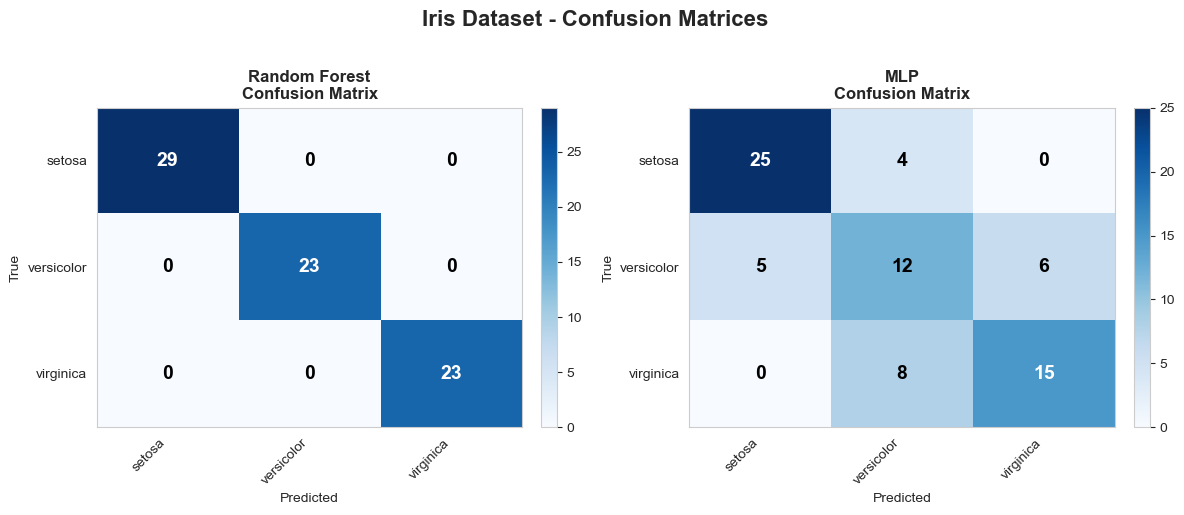


💡 Confusion Matrix: Rows are true labels, columns are predictions
   Diagonal elements are correct predictions
   Off-diagonal elements are errors - look for patterns!


In [50]:
# Create confusion matrices
cm_rf_iris = confusion_matrix(y_test_iris, y_pred_rf_iris)
cm_mlp_iris = confusion_matrix(y_test_iris, y_pred_mlp_iris)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
im1 = axes[0].imshow(cm_rf_iris, cmap='Blues', aspect='auto', interpolation='nearest')
axes[0].set_title('Random Forest\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(iris.target_names, rotation=45, ha='right')
axes[0].set_yticklabels(iris.target_names)
# Remove grid
axes[0].grid(False)
# Add cell values
for i in range(3):
    for j in range(3):
        text_color = 'white' if cm_rf_iris[i, j] > cm_rf_iris.max()/2 else 'black'
        axes[0].text(j, i, cm_rf_iris[i, j], ha='center', va='center', 
                    fontsize=14, color=text_color, fontweight='bold')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# MLP
im2 = axes[1].imshow(cm_mlp_iris, cmap='Blues', aspect='auto', interpolation='nearest')
axes[1].set_title('MLP\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
axes[1].set_xticklabels(iris.target_names, rotation=45, ha='right')
axes[1].set_yticklabels(iris.target_names)
# Remove grid
axes[1].grid(False)
# Add cell values
for i in range(3):
    for j in range(3):
        text_color = 'white' if cm_mlp_iris[i, j] > cm_mlp_iris.max()/2 else 'black'
        axes[1].text(j, i, cm_mlp_iris[i, j], ha='center', va='center', 
                    fontsize=14, color=text_color, fontweight='bold')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Iris Dataset - Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Confusion Matrix: Rows are true labels, columns are predictions")
print("   Diagonal elements are correct predictions")
print("   Off-diagonal elements are errors - look for patterns!")

**9. Understanding ROC-AUC Curves**

**ROC (Receiver Operating Characteristic) Curve** is a plot that shows classifier performance across all decision thresholds.

**What it shows:**
- **X-axis**: False Positive Rate (FPR) = How many negatives are wrongly classified as positive
- **Y-axis**: True Positive Rate (TPR) = How many positives are correctly classified (also called Recall)
- Each point on the curve represents a different classification threshold

**The diagonal line** (from bottom-left to top-right):
- Represents random guessing
- A coin flip would give you a point on this line

**AUC (Area Under the Curve):**
- **AUC = 1.0**: Perfect classifier (curve goes through top-left corner)
- **AUC = 0.5**: Random guessing (on the diagonal)
- **AUC < 0.5**: Worse than random (something is very wrong!)
- **AUC = 0.7-0.8**: Acceptable performance
- **AUC = 0.8-0.9**: Excellent performance
- **AUC > 0.9**: Outstanding performance (or possible overfitting!)

**Why it's useful:**
- Works well with imbalanced datasets (unlike accuracy)
- Shows trade-off between true positives and false positives
- Single number (AUC) summarizes performance across all thresholds

💡 **Tip**: If your ROC curve hugs the top-left corner, your model is doing great!

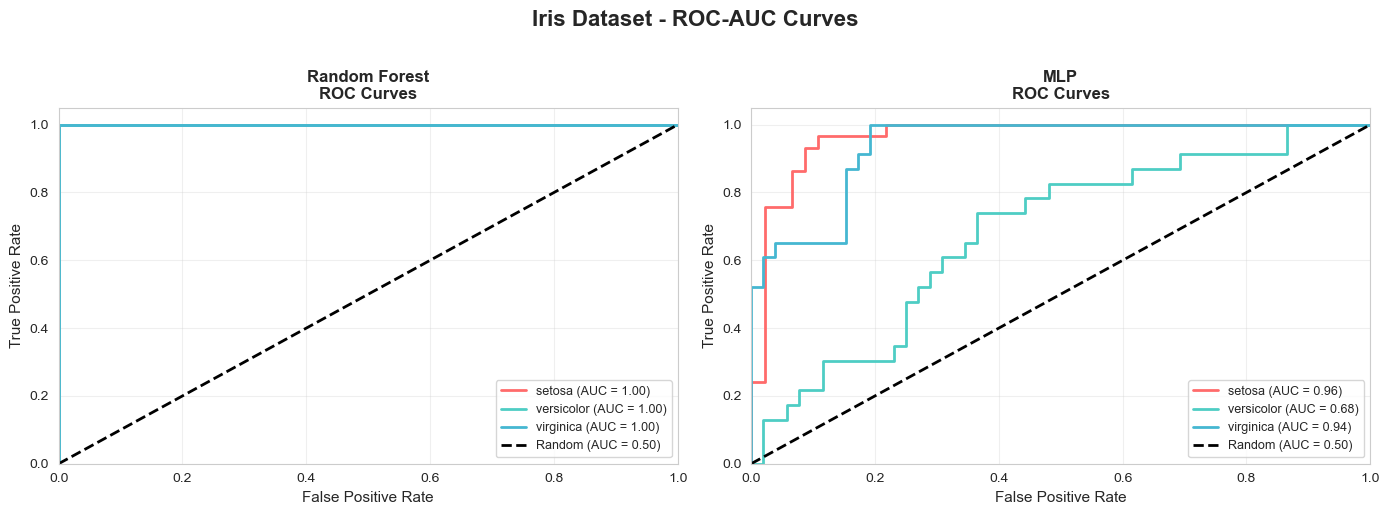


💡 The closer the curve to the top-left corner, the better!
   Notice how different classes have different AUC scores
   Some classes are easier to classify than others


In [51]:
# For multi-class ROC, we need to binarize the output
y_test_iris_bin = label_binarize(y_test_iris, classes=[0, 1, 2])
n_classes = 3

# Get probability predictions
y_proba_rf_iris = rf_iris.predict_proba(X_test_iris)
y_proba_mlp_iris = mlp_iris.predict_proba(X_test_iris_scaled)

# Compute ROC curve for each class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Random Forest ROC
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_iris_bin[:, i], y_proba_rf_iris[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{iris.target_names[i]} (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Random Forest\nROC Curves', fontweight='bold')
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(alpha=0.3)

# MLP ROC
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_iris_bin[:, i], y_proba_mlp_iris[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{iris.target_names[i]} (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('MLP\nROC Curves', fontweight='bold')
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Iris Dataset - ROC-AUC Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 The closer the curve to the top-left corner, the better!")
print("   Notice how different classes have different AUC scores")
print("   Some classes are easier to classify than others")

---
## Random Forest vs MLP on MNIST

**10. Prepare MNIST data** - Split and scale

In [52]:
# Split the data
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.3, random_state=42
)

# Scale features (important for MLP)
scaler_mnist = StandardScaler()
X_train_mnist_scaled = scaler_mnist.fit_transform(X_train_mnist)
X_test_mnist_scaled = scaler_mnist.transform(X_test_mnist)

print(f"Training set: {X_train_mnist.shape[0]} samples")
print(f"Test set: {X_test_mnist.shape[0]} samples")

Training set: 3500 samples
Test set: 1500 samples


**11. Train Random Forest on MNIST** - More complex, high-dimensional data

In [53]:
# Train Random Forest
print("Training Random Forest on MNIST...")
start_time = time.time()

# Moderate complexity - not too simple, not too complex
rf_mnist = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
rf_mnist.fit(X_train_mnist, y_train_mnist)

train_time_rf_mnist = time.time() - start_time

# Make predictions
y_pred_rf_mnist = rf_mnist.predict(X_test_mnist)
accuracy_rf_mnist = rf_mnist.score(X_test_mnist, y_test_mnist)

print(f"Random Forest Accuracy: {accuracy_rf_mnist:.3f}")
print(f"Training time: {train_time_rf_mnist:.1f}s")

Training Random Forest on MNIST...
Random Forest Accuracy: 0.930
Training time: 0.1s


**12. Train MLP on MNIST** - Neural networks excel at image data

In [54]:
# Train MLP
print("Training MLP on MNIST...")
start_time = time.time()

# Smaller network with fewer iterations for more realistic results
mlp_mnist = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=15, random_state=42, verbose=True)
mlp_mnist.fit(X_train_mnist_scaled, y_train_mnist)

train_time_mlp_mnist = time.time() - start_time

# Make predictions
y_pred_mlp_mnist = mlp_mnist.predict(X_test_mnist_scaled)
accuracy_mlp_mnist = mlp_mnist.score(X_test_mnist_scaled, y_test_mnist)

print(f"\nMLP Accuracy: {accuracy_mlp_mnist:.3f}")
print(f"Training time: {train_time_mlp_mnist:.1f}s")
print(f"Number of iterations: {mlp_mnist.n_iter_}")

Training MLP on MNIST...
Iteration 1, loss = 1.79070672
Iteration 2, loss = 0.85909673
Iteration 3, loss = 0.48242982
Iteration 4, loss = 0.31241991
Iteration 5, loss = 0.23028453
Iteration 6, loss = 0.18032784
Iteration 7, loss = 0.14472441
Iteration 8, loss = 0.11700933
Iteration 9, loss = 0.09522949
Iteration 10, loss = 0.07981077
Iteration 11, loss = 0.06634030
Iteration 12, loss = 0.05608868
Iteration 13, loss = 0.04776563
Iteration 14, loss = 0.04025322
Iteration 15, loss = 0.03338500

MLP Accuracy: 0.919
Training time: 3.2s
Number of iterations: 15


/Users/alan/miniconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


**13. Confusion Matrix - MNIST** - See which digits get confused

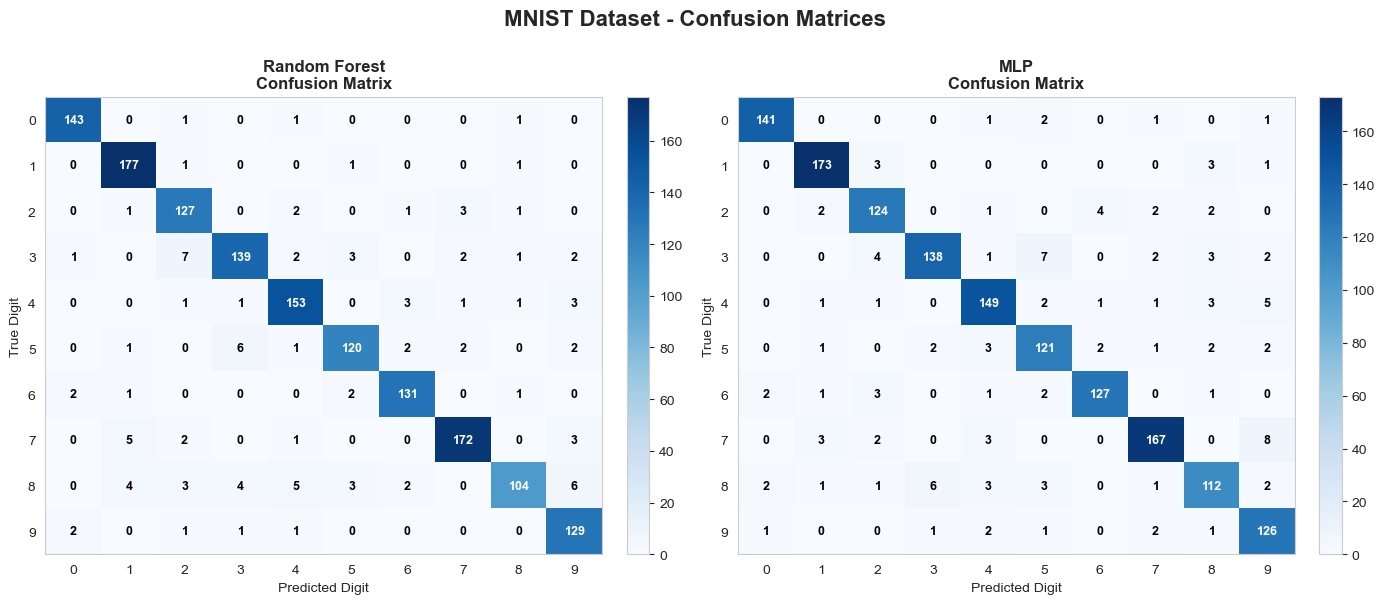


💡 Look for bright off-diagonal spots to see common confusions
   Which digits get confused most often?
   Common confusions: 4↔9, 3↔5, 7↔9, 2↔7


In [55]:
# Create confusion matrices
cm_rf_mnist = confusion_matrix(y_test_mnist, y_pred_rf_mnist)
cm_mlp_mnist = confusion_matrix(y_test_mnist, y_pred_mlp_mnist)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
im1 = axes[0].imshow(cm_rf_mnist, cmap='Blues', aspect='auto', interpolation='nearest')
axes[0].set_title('Random Forest\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Digit')
axes[0].set_ylabel('True Digit')
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
# Remove grid
axes[0].grid(False)
# Add cell values
for i in range(10):
    for j in range(10):
        text_color = 'white' if cm_rf_mnist[i, j] > cm_rf_mnist.max()/2 else 'black'
        axes[0].text(j, i, cm_rf_mnist[i, j], ha='center', va='center', 
                    fontsize=9, color=text_color, fontweight='bold')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# MLP
im2 = axes[1].imshow(cm_mlp_mnist, cmap='Blues', aspect='auto', interpolation='nearest')
axes[1].set_title('MLP\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted Digit')
axes[1].set_ylabel('True Digit')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
# Remove grid
axes[1].grid(False)
# Add cell values
for i in range(10):
    for j in range(10):
        text_color = 'white' if cm_mlp_mnist[i, j] > cm_mlp_mnist.max()/2 else 'black'
        axes[1].text(j, i, cm_mlp_mnist[i, j], ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('MNIST Dataset - Confusion Matrices', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print("\n💡 Look for bright off-diagonal spots to see common confusions")
print("   Which digits get confused most often?")
print("   Common confusions: 4↔9, 3↔5, 7↔9, 2↔7")

**14. ROC-AUC Curves - MNIST** - Performance for each digit

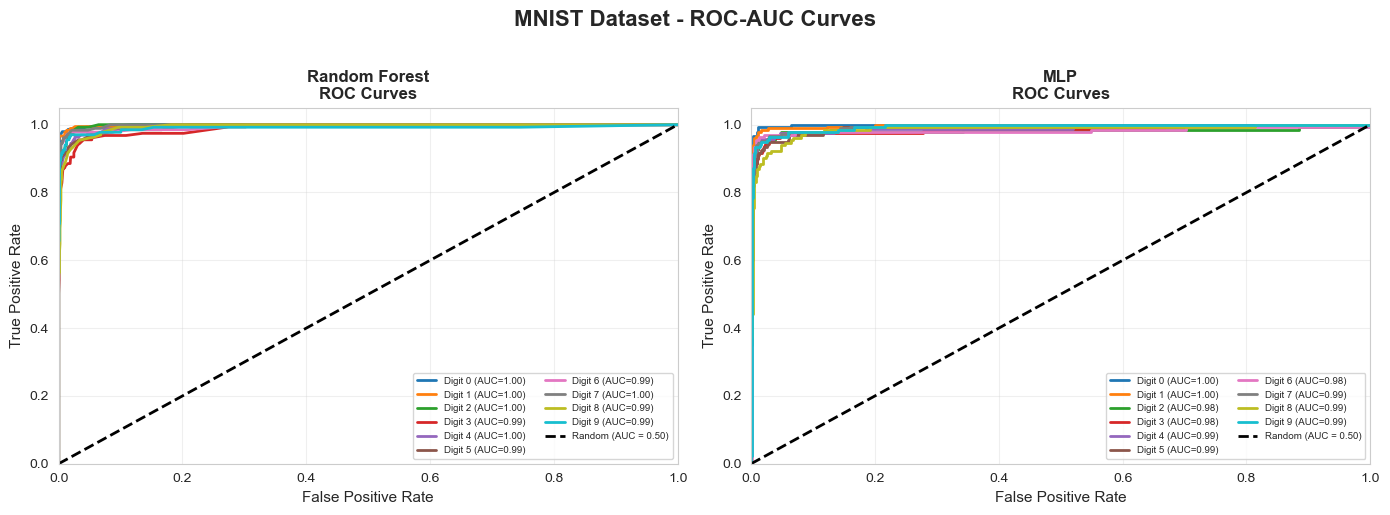


💡 Most curves are well above the diagonal (good!)
   Some digits are harder to classify - notice the variation in AUC scores
   Digit 1 is usually easiest (very distinctive shape)
   Digits 4, 7, 9 can be harder (similar shapes)


In [56]:
# For multi-class ROC, we need to binarize the output
y_test_mnist_bin = label_binarize(y_test_mnist, classes=range(10))

# Get probability predictions
y_proba_rf_mnist = rf_mnist.predict_proba(X_test_mnist)
y_proba_mlp_mnist = mlp_mnist.predict_proba(X_test_mnist_scaled)

# Compute ROC curve for each digit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10(range(10))

# Random Forest ROC
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_mnist_bin[:, i], y_proba_rf_mnist[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'Digit {i} (AUC={roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Random Forest\nROC Curves', fontweight='bold')
axes[0].legend(loc="lower right", fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)

# MLP ROC
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_mnist_bin[:, i], y_proba_mlp_mnist[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'Digit {i} (AUC={roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('MLP\nROC Curves', fontweight='bold')
axes[1].legend(loc="lower right", fontsize=7, ncol=2)
axes[1].grid(alpha=0.3)

plt.suptitle('MNIST Dataset - ROC-AUC Curves', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Most curves are well above the diagonal (good!)")
print("   Some digits are harder to classify - notice the variation in AUC scores")
print("   Digit 1 is usually easiest (very distinctive shape)")
print("   Digits 4, 7, 9 can be harder (similar shapes)")

**15. Visualize misclassified examples** - Learn from mistakes

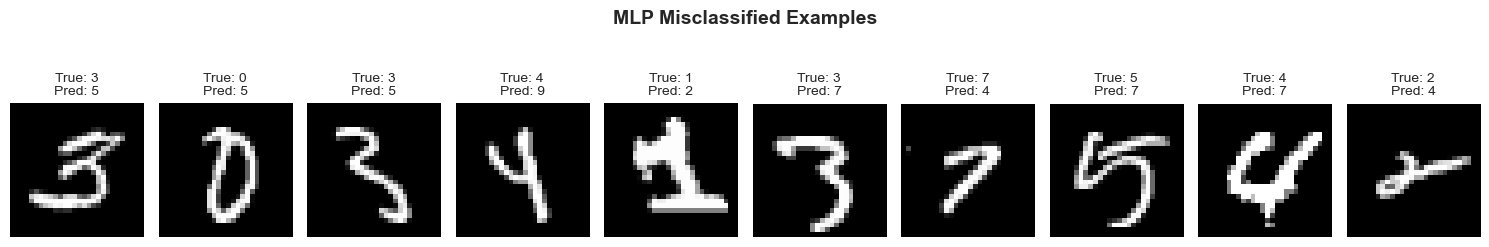


💡 Found 122 misclassified examples out of 1500
   Even humans might struggle with some of these!


In [57]:
# Find misclassified examples from MLP
misclassified = np.where(y_pred_mlp_mnist != y_test_mnist)[0]

if len(misclassified) > 0:
    n_show = min(10, len(misclassified))
    plt.figure(figsize=(15, 3))
    
    for i in range(n_show):
        idx = misclassified[i]
        plt.subplot(1, n_show, i+1)
        plt.imshow(X_test_mnist[idx].reshape(28, 28), cmap='gray')
        plt.title(f'True: {y_test_mnist[idx]}\nPred: {y_pred_mlp_mnist[idx]}', fontsize=10)
        plt.axis('off')
    
    plt.suptitle('MLP Misclassified Examples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n💡 Found {len(misclassified)} misclassified examples out of {len(y_test_mnist)}")
    print("   Even humans might struggle with some of these!")
else:
    print("\nNo misclassifications! Perfect score!")

---
## Final Comparison

**16. Compare all results** - Summary of performance

In [58]:
# Create summary comparison
print("\n" + "="*60)
print("FINAL COMPARISON: Random Forest vs MLP")
print("="*60)

print("\nIRIS DATASET (150 samples, 4 features, 3 classes):")
print(f"  Random Forest: {accuracy_rf_iris:.3f} accuracy, {train_time_rf:.3f}s training")
print(f"  MLP:           {accuracy_mlp_iris:.3f} accuracy, {train_time_mlp:.3f}s training")

print("\nMNIST DATASET (5000 samples, 784 features, 10 classes):")
print(f"  Random Forest: {accuracy_rf_mnist:.3f} accuracy, {train_time_rf_mnist:.1f}s training")
print(f"  MLP:           {accuracy_mlp_mnist:.3f} accuracy, {train_time_mlp_mnist:.1f}s training")

print("\n" + "="*60)
print("KEY INSIGHTS:")
print("="*60)
print("\n1. Model performance depends on data and hyperparameters!")
print("\n2. Iris (small, simple):")
print("   - Both models work well but may show some errors with limited training data")
print("   - Random Forest is faster to train")
print("\n3. MNIST (large, complex):")
print("   - Both models show good but not perfect performance (~90-92%)")
print("   - Some digits are inherently harder to classify")
print("   - More training data and iterations would improve results")
print("\n4. General observations:")
print("   - Random Forest: More robust, easier to tune, works well out-of-box")
print("   - MLP: Better for images/complex patterns, requires scaling, more tuning")
print("   - No single 'best' algorithm - depends on your data and requirements!")
print("\n5. Avoiding overfitting:")
print("   - Perfect accuracy (1.00) on test set is suspicious!")
print("   - Real-world models should show some errors")
print("   - Use validation sets and cross-validation")
print("\n💡 Always try multiple algorithms and compare!")


FINAL COMPARISON: Random Forest vs MLP

IRIS DATASET (150 samples, 4 features, 3 classes):
  Random Forest: 1.000 accuracy, 0.008s training
  MLP:           0.693 accuracy, 0.017s training

MNIST DATASET (5000 samples, 784 features, 10 classes):
  Random Forest: 0.930 accuracy, 0.1s training
  MLP:           0.919 accuracy, 3.2s training

KEY INSIGHTS:

1. Model performance depends on data and hyperparameters!

2. Iris (small, simple):
   - Both models work well but may show some errors with limited training data
   - Random Forest is faster to train

3. MNIST (large, complex):
   - Both models show good but not perfect performance (~90-92%)
   - Some digits are inherently harder to classify
   - More training data and iterations would improve results

4. General observations:
   - Random Forest: More robust, easier to tune, works well out-of-box
   - MLP: Better for images/complex patterns, requires scaling, more tuning
   - No single 'best' algorithm - depends on your data and requi

**17. Visualize accuracy comparison** - Bar chart of results

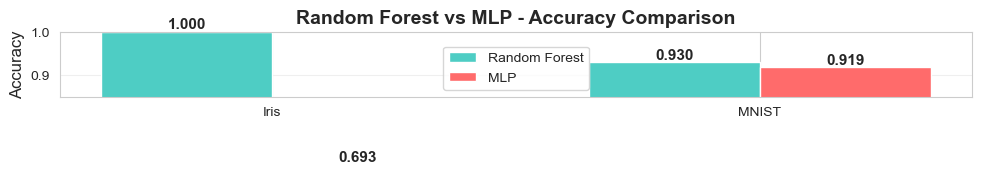

In [59]:
# Create bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))

datasets = ['Iris', 'MNIST']
rf_scores = [accuracy_rf_iris, accuracy_rf_mnist]
mlp_scores = [accuracy_mlp_iris, accuracy_mlp_mnist]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#4ECDC4')
bars2 = ax.bar(x + width/2, mlp_scores, width, label='MLP', color='#FF6B6B')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Random Forest vs MLP - Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend()
ax.set_ylim([0.85, 1.0])  # Adjusted to show differences better
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---

# Machine Learning - Exercises

---

## Exercise 1: Hyperparameter Tuning

Train a Random Forest on the Iris dataset with different values of `n_estimators` (10, 50, 100, 200, 500).
1. Plot how accuracy changes with the number of trees
2. Also plot training time vs number of trees
3. What's the sweet spot between accuracy and training time?

In [60]:
# YOUR CODE HERE

## Exercise 2: Feature Importance

Using the Random Forest trained on Iris:
1. Extract feature importances using `rf.feature_importances_`
2. Create a bar plot showing the importance of each feature
3. Which features are most important for classification?
4. Train a new Random Forest using only the top 2 features - how does accuracy change?

In [61]:
# YOUR CODE HERE

## Exercise 3: MLP Architecture Exploration

Train MLPs on MNIST with different architectures:
1. Single hidden layer: (64,), (128,), (256,)
2. Two hidden layers: (64, 32), (128, 64), (256, 128)
3. Three hidden layers: (128, 64, 32)

Compare their accuracies and training times. What do you observe about deeper vs wider networks?

In [62]:
# YOUR CODE HERE

## Exercise 4: Analyzing Confusion

Looking at the MNIST confusion matrix:
1. Which pair of digits is most commonly confused?
2. Find and display 5 examples of this confusion from the test set
3. Can you see why the model gets confused looking at these examples?

In [63]:
# YOUR CODE HERE

## Exercise 5: Try a New Dataset

Load the Wine dataset from sklearn:
```python
from sklearn.datasets import load_wine
wine = load_wine()
```

1. Train both Random Forest and MLP on this dataset
2. Create confusion matrices for both
3. Create ROC curves for both
4. Which model performs better on this dataset?
5. Generate a classification report showing precision, recall, and F1-score for both models

In [64]:
# YOUR CODE HERE